In [1]:
# Import necessary libraries
import os
import glob
from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision
torchvision.disable_beta_transforms_warning()
import torchvision.transforms.v2 as transforms

from PIL import Image

import utils
import vision_transformer as vits

In [2]:
# define dataset class
class ImageDataset(Dataset):
    def __init__(self, image_path_list, transform=None):
        self.image_path_list = image_path_list
        self.transform = transform

    def __len__(self):
        return len(self.image_path_list)

    def __getitem__(self, idx):
        img_path = self.image_path_list[idx]
        image = Image.open(img_path)
        if image.mode == "L":
            image = image.convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

In [3]:
# parameters
training_method = "dino"
depth_list = [8, 12]
num_models = 6
num_heads = 6
patch_size = 16
batch_size = 10
slice_layer = {"8": [6, 7], "12": [8, 9]} # indices of slice layer
total_heads = len(depth_list) * len(slice_layer["8"]) * num_models * num_heads  # = 144

In [ ]:
# transform of images
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.ToImage(),
    transforms.ConvertImageDtype(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])

In [5]:
# device for pytorch
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# loading multiple models
depth_list = [8, 12]
num_models = 6
models_dict = {} # 2 (depth) x 6 (trial) models
for i, depth in enumerate(depth_list):
    models = [vits.__dict__["vit_small"](patch_size=patch_size, depth=depth) for _ in range(num_models)]
    load_path = f'./model_data/vits_depth{depth}_dino_six_models.pth' # path for models
    checkpoint = torch.load(load_path)
    
    for j, model in tqdm(enumerate(models), total=num_models):
        model.load_state_dict(checkpoint[f'model_{j}'])
        for p in model.parameters():
            p.requires_grad = False
        model.eval()
        model.to(device)
    models_dict[str(depth)] = models

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

In [6]:
# Change this path to the directory containing the images you want to use
image_path_list = sorted(glob.glob("./test_images/*"))

# dataset for loading images
dataset = ImageDataset(image_path_list, transform)
dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=False)

In [7]:
# get 144 heads activities and attentions 
activities_all = []
attentions_all = []
for depth in depth_list:
    activities_depth = []
    attentions_depth = []
    for i in tqdm(range(num_models)):
        model = models_dict[str(depth)][i]
        
        activities_list = []
        attentions_list = []
        w_featmap, h_featmap = None, None
        for images in dataloader:
            # images: batch_size x 3 channel x heights x width
            with torch.inference_mode():
                """
                activities [depth x (batch size x num. heads x embed. dims.)]: list of [softmax(q_cls * K) * V]
                attentions [depth x (batch size x num. heads x num. tokens)] : list of [softmax(q_cls * K)]
                """
                activities, attentions = model.get_all_head_activity(images.to(device))
            num_samples = len(images)
            if w_featmap is None:
                w_featmap = images.shape[-2] // patch_size
                h_featmap = images.shape[-1] // patch_size
            # cls activity
            activities_batch = torch.stack([activities[slice_layer[str(depth)][i]] for i in range(2)], dim=1)
            activities_list.append(activities_batch)
            
            # cls attention map
            attentions_ = []
            for i in range(len(slice_layer[str(depth)])):
                layer_idx = slice_layer[str(depth)][i]
                attn = attentions[layer_idx]
                attn = attn.reshape(num_samples, num_heads, w_featmap, h_featmap)#.detach().cpu().numpy()
                attentions_.append(attn)
            attentions_batch = torch.stack(attentions_, dim=1)
            attentions_list.append(attentions_batch)
        activities_concat = torch.vstack(activities_list).detach().cpu().numpy() # num_images x 2 layers x 6 heads x 64 dims
        attentions_concat = torch.vstack(attentions_list).detach().cpu().numpy() # num_images x 2 layers x 6 heads x height x width
    
        activities_depth.append(activities_concat[:, :, None, :])
        attentions_depth.append(attentions_concat[:, :, None, :])
    activities_depth = np.dstack(activities_depth)
    attentions_depth = np.dstack(attentions_depth)
    activities_all.append(activities_depth[:, None, :])
    attentions_all.append(attentions_depth[:, None, :])
activities_all = np.hstack(activities_all).reshape(len(dataset), total_heads, -1)
attentions_all = np.hstack(attentions_all).reshape(len(dataset), total_heads, w_featmap, h_featmap)
print(f"activities: {activities_all.shape}, attentions: {attentions_all.shape}")

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

activities: (14, 144, 64), attentions: (14, 144, 16, 16)


In [8]:
# get label for 144 heads (in [1,2,3])
labels = np.load("./model_data/attn_best_label_N2010.npz")["head_labels"].flatten()
print(np.unique(labels, return_counts=True))

(array([1, 2, 3], dtype=int32), array([24, 92, 28]))


In [9]:
# get group activities and attentions
activities_dict = {}
attentions_dict = {}
num_groups = 3
for i in range(1, num_groups+1):
    idx = labels == i
    activities_dict[i] = activities_all[:, idx]
    attentions_dict[i] = attentions_all[:, idx]
    print(f"G{i}: activities {activities_dict[i].shape}, attentions {attentions_dict[i].shape}")

G1: activities (14, 24, 64), attentions (14, 24, 16, 16)
G2: activities (14, 92, 64), attentions (14, 92, 16, 16)
G3: activities (14, 28, 64), attentions (14, 28, 16, 16)


In [10]:
# get group mean attentions
attentions_mean = []
for i in range(1, num_groups+1):
    attentions_mean.append(np.mean(attentions_dict[i], axis=1))

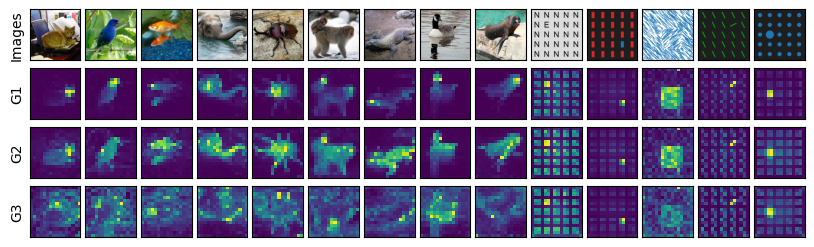

In [11]:
# visualization of mean attention maps 
imgs = [Image.open(image_path) for image_path in image_path_list]

fig, axes = plt.subplots(4, len(imgs), figsize=(10, 3))
for i in range(len(imgs)):
    axes[0, i].imshow(imgs[i])
    for j in range(num_groups):
        axes[j+1, i].imshow(attentions_mean[j][i])
    for k in range(num_groups+1):
        axes[k, i].set_xticks([])
        axes[k, i].set_yticks([])

axes[0, 0].set_ylabel("Images")
for j in range(num_groups):
    axes[j+1, 0].set_ylabel(f"G{j+1}")
fig.subplots_adjust(wspace=0.1, hspace=0.1)
fig.savefig("mean_attention_maps.png", dpi=100, bbox_inches='tight', pad_inches=0.1)